# INSTALL & IMPORT

In [ ]:
!pip install kagglehub split-folders -q

import kagglehub
import splitfolders
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# DOWNLOAD DATASET

In [ ]:
from google.colab import drive
import os
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# Path to your zip file
zip_path = "/content/drive/MyDrive/archive.zip"

# Extract location
extract_path = "/content/dataset"

# Unzip the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Set dataset path (same logic as before)
path = extract_path

# handle nested folder (same as your original code)
if len(os.listdir(path)) == 1:
    path = os.path.join(path, os.listdir(path)[0])

print("Original folders:", os.listdir(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original folders: ['Maize', 'Scentless Mayweed', 'ShepherdΓÇÖs Purse', 'Black-grass', 'Cleavers', 'Common Chickweed', 'Small-flowered Cranesbill', 'Loose Silky-bent', 'Charlock', 'nonsegmentedv2', 'Sugar beet', 'Fat Hen', 'Common wheat']


In [ ]:
import os
import shutil

# Fix class name: ShepherdΓÇÖs Purse -> Shepherds Purse
old_name = os.path.join(path, "ShepherdΓÇÖs Purse")
new_name = os.path.join(path, "Shepherds Purse")

if os.path.exists(old_name):
    os.rename(old_name, new_name)
    print("Renamed class to: Shepherds Purse")

# Delete unwanted class: nonsegmentedv2
remove_class = os.path.join(path, "nonsegmentedv2")

if os.path.exists(remove_class):
    shutil.rmtree(remove_class)
    print("Deleted class: nonsegmentedv2")

# Final check
print("Updated folders:", os.listdir(path))

Renamed class to: Shepherds Purse
Deleted class: nonsegmentedv2
Updated folders: ['Maize', 'Scentless Mayweed', 'Black-grass', 'Cleavers', 'Common Chickweed', 'Small-flowered Cranesbill', 'Shepherds Purse', 'Loose Silky-bent', 'Charlock', 'Sugar beet', 'Fat Hen', 'Common wheat']


# herbicide

In [ ]:
herbicide_db = {
    "Black-grass": [
        {"name": "Alister Flex", "type": "Post-emergent", "dose": "100 ml"},
        {"name": "Clethodim Mix", "type": "Post-emergent", "dose": "200 ml"},
        {"name": "Broadway Star", "type": "Post-emergent", "dose": "200 ml"}
    ],

    "Charlock": [
        {"name": "2,4-D Amine", "type": "Post-emergent", "dose": "500 ml"},
        {"name": "MCPA", "type": "Post-emergent", "dose": "400 ml"},
        {"name": "Dicamba", "type": "Post-emergent", "dose": "250 ml"}
    ],

    "Cleavers": [
        {"name": "Fluroxypyr", "type": "Post-emergent", "dose": "200 ml"},
        {"name": "Clopyralid", "type": "Post-emergent", "dose": "300 ml"},
        {"name": "Metsulfuron-methyl", "type": "Post-emergent", "dose": "20 g"}
    ],

    "Common Chickweed": [
        {"name": "Pendimethalin", "type": "Pre-emergent", "dose": "1 L"},
        {"name": "Fluroxypyr", "type": "Post-emergent", "dose": "300 ml"},
        {"name": "Metribuzin", "type": "Post-emergent", "dose": "200 ml"}
    ],

    "Common wheat": [
        {"name": "No herbicide", "type": "Crop", "dose": "-"},
        {"name": "Selective herbicide only", "type": "Crop", "dose": "-"},
        {"name": "Crop safe chemicals", "type": "Crop", "dose": "-"}
    ],

    "Fat Hen": [
        {"name": "Atrazine", "type": "Pre-emergent", "dose": "1.5 L"},
        {"name": "Glyphosate", "type": "Post-emergent", "dose": "500 ml"},
        {"name": "Metolachlor", "type": "Pre-emergent", "dose": "1 L"}
    ],

    "Loose Silky-bent": [
        {"name": "Clodinafop", "type": "Post-emergent", "dose": "250 ml"},
        {"name": "Fenoxaprop", "type": "Post-emergent", "dose": "300 ml"},
        {"name": "Pinoxaden", "type": "Post-emergent", "dose": "500 ml"}
    ],

    "Maize": [
        {"name": "No herbicide", "type": "Crop", "dose": "-"},
        {"name": "Selective only", "type": "Crop", "dose": "-"},
        {"name": "Crop safe", "type": "Crop", "dose": "-"}
    ],

    "Scentless Mayweed": [
        {"name": "MCPA", "type": "Post-emergent", "dose": "500 ml"},
        {"name": "Fluroxypyr", "type": "Post-emergent", "dose": "200 ml"},
        {"name": "2,4-D", "type": "Post-emergent", "dose": "600 ml"}
    ],

    "Shepherds Purse": [
        {"name": "Glyphosate", "type": "Post-emergent", "dose": "1 L"},
        {"name": "2,4-D", "type": "Post-emergent", "dose": "500 ml"},
        {"name": "Dicamba", "type": "Post-emergent", "dose": "250 ml"}
    ],

    "Small-flowered Cranesbill": [
        {"name": "Fluroxypyr", "type": "Post-emergent", "dose": "200 ml"},
        {"name": "Clopyralid", "type": "Post-emergent", "dose": "300 ml"},
        {"name": "MCPA", "type": "Post-emergent", "dose": "500 ml"}
    ],

    "Sugar beet": [
        {"name": "No herbicide", "type": "Crop", "dose": "-"},
        {"name": "Selective only", "type": "Crop", "dose": "-"},
        {"name": "Crop safe", "type": "Crop", "dose": "-"}
    ],

    "Sugar beet weed": [
        {"name": "Phenmedipham", "type": "Post-emergent", "dose": "1 L"},
        {"name": "Desmedipham", "type": "Post-emergent", "dose": "800 ml"},
        {"name": "Ethofumesate", "type": "Pre-emergent", "dose": "1 L"}
    ]
}

# FIND IMAGE FOLDER

In [ ]:
dataset_path = os.path.join(path, "images") if "images" in os.listdir(path) else path

print("Using dataset path:", dataset_path)
print(os.listdir(dataset_path))

Using dataset path: /content/dataset
['Maize', 'Scentless Mayweed', 'Black-grass', 'Cleavers', 'Common Chickweed', 'Small-flowered Cranesbill', 'Shepherds Purse', 'Loose Silky-bent', 'Charlock', 'Sugar beet', 'Fat Hen', 'Common wheat']


# SPLIT DATA

In [ ]:
splitfolders.ratio(
    dataset_path,
    output="/content/weed_split",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 5539 files [00:21, 261.77 files/s]


# PARAMETERS

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

# DATA AUGMENTATION

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# LOAD DATA

In [ ]:
train_data = train_datagen.flow_from_directory(
    "/content/weed_split/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    "/content/weed_split/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    "/content/weed_split/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3872 images belonging to 12 classes.
Found 825 images belonging to 12 classes.
Found 842 images belonging to 12 classes.


# BUILD MODEL

In [ ]:
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers[:100]:
    layer.trainable = False

for layer in base_model.layers[100:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(train_data.num_classes, activation='softmax')
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# COMPILE

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# CALLBACKS

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.3, verbose=1)
]

# TRAIN

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 163s 827ms/step - accuracy: 0.2188 - loss: 2.6376 - val_accuracy: 0.5139 - val_loss: 1.8219 - learning_rate: 1.0000e-04
Epoch 2/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 80s 665ms/step - accuracy: 0.5008 - loss: 1.7412 - val_accuracy: 0.7624 - val_loss: 1.1611 - learning_rate: 1.0000e-04
Epoch 3/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 79s 652ms/step - accuracy: 0.6896 - loss: 1.3229 - val_accuracy: 0.8509 - val_loss: 0.9537 - learning_rate: 1.0000e-04
Epoch 4/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 80s 660ms/step - accuracy: 0.7681 - loss: 1.1533 - val_accuracy: 0.8691 - val_loss: 0.9136 - learning_rate: 1.0000e-04
Epoch 5/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 79s 656ms/step - accuracy: 0.8200 - loss: 1.0424 - val_accuracy: 0.8970 - val_loss: 0.8353 - learning_rate: 1.0000e-04
Epoch 6/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 79s 650ms/step - accuracy: 0.8438 - loss: 0.9887 - val_accuracy: 0.9103 - val_loss: 0.8094 - learning_rate: 1.0000e-04
Epoch 7/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 80s 6

# EVALUATE

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 649ms/step - accuracy: 0.9679 - loss: 0.6376

Test Accuracy: 96.79%


# CONFUSION MATRIX

27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 484ms/step


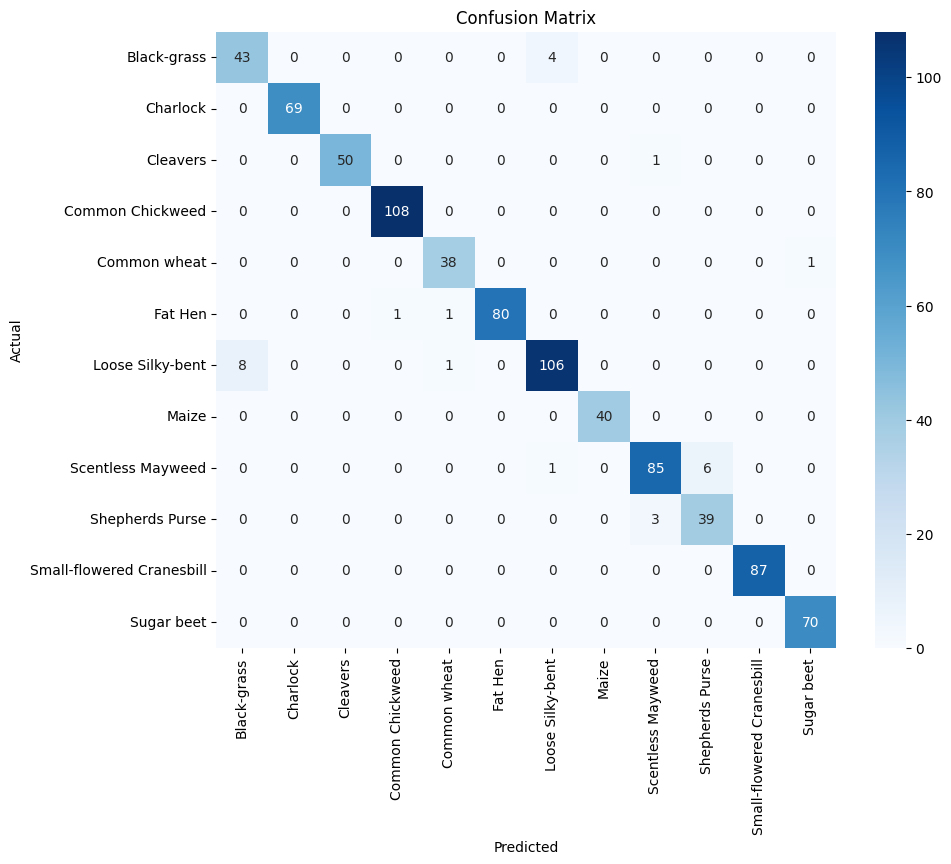

In [ ]:
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# CLASSIFICATION REPORT

In [ ]:
print("\nClassification Report:\n")

labels = np.unique(y_true)  # only labels present

class_names = list(train_data.class_indices.keys())
filtered_names = [class_names[i] for i in labels]

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=filtered_names
))


Classification Report:

                           precision    recall  f1-score   support

              Black-grass       0.84      0.91      0.88        47
                 Charlock       1.00      1.00      1.00        69
                 Cleavers       1.00      0.98      0.99        51
         Common Chickweed       0.99      1.00      1.00       108
             Common wheat       0.95      0.97      0.96        39
                  Fat Hen       1.00      0.98      0.99        82
         Loose Silky-bent       0.95      0.92      0.94       115
                    Maize       1.00      1.00      1.00        40
        Scentless Mayweed       0.96      0.92      0.94        92
          Shepherds Purse       0.87      0.93      0.90        42
Small-flowered Cranesbill       1.00      1.00      1.00        87
               Sugar beet       0.99      1.00      0.99        70

                 accuracy                           0.97       842
                macro avg       0.9

# PLOTS

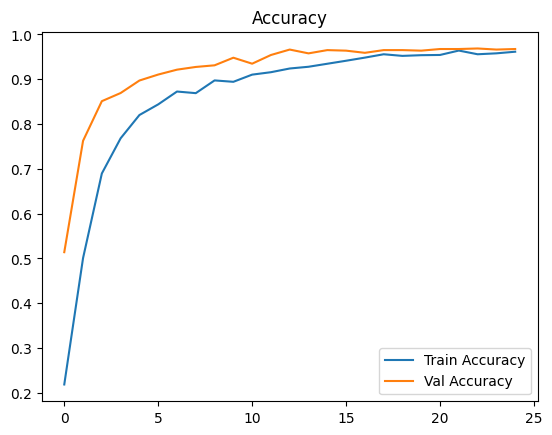

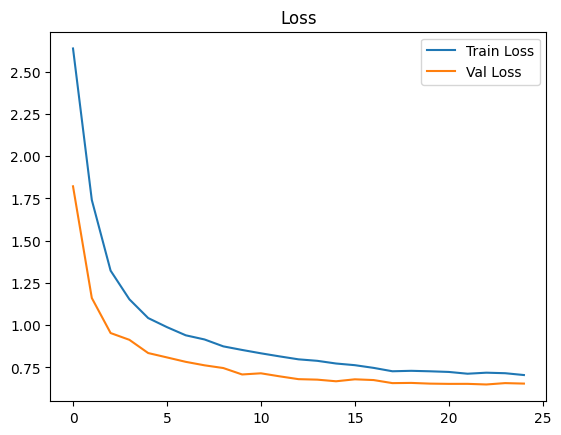

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

# Herbicide Recommendation

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_weed(img_path, model, class_names):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = preprocess_input(image.img_to_array(img))
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)

    class_index = np.argmax(preds)
    confidence = np.max(preds)

    weed_name = class_names[class_index]

    return weed_name, confidence

In [ ]:
def get_herbicides(weed_name):
    if weed_name in herbicide_db:
        return herbicide_db[weed_name][:5]
    else:
        return [{"name": "No herbicide data available"}]

In [ ]:
def analyze_image(img_path, model, class_names):
    weed, confidence = predict_weed(img_path, model, class_names)
    herbicides = get_herbicides(weed)

    print("===================================")
    print(f"Image: {img_path}")
    print(f"Detected Weed: {weed}")
    print(f"Confidence: {confidence*100:.2f}%")

    print("\nRecommended Herbicides:\n")

    for i, herb in enumerate(herbicides):
        print(f"{i+1}. Name: {herb.get('name','N/A')}")
        print(f"   Type: {herb.get('type','N/A')}")
        print(f"   Dose: {herb.get('dose','N/A')}")
        print()

    print("===================================\n")

In [ ]:
from google.colab import files

uploaded = files.upload()

for img_name in uploaded.keys():
    analyze_image(img_name, model, class_names)

Saving 23.png to 23.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Image: 23.png
Detected Weed: Shepherds Purse
Confidence: 94.44%

Recommended Herbicides:

1. Name: Glyphosate
   Type: Post-emergent
   Dose: 1 L

2. Name: 2,4-D
   Type: Post-emergent
   Dose: 500 ml

3. Name: Dicamba
   Type: Post-emergent
   Dose: 250 ml




In [ ]:
import os

test_folder = "/content/data"  # change path if needed

for root, dirs, files in os.walk(test_folder):
    for file in files[:5]:
        if file.endswith((".jpg", ".png", ".jpeg")):
            path = os.path.join(root, file)
            analyze_image(path, model, class_names)

# SAVE MODEL

In [ ]:
model.save("/content/weed_model_final.keras")